In [1]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [2]:
%%R

library(readr)
library(tidyr)
library(tibble)
library(car)
library(outliers)
library(corrplot)
library(mice)
library(nortest)
library(ggplot2)
library(dplyr)
library(gridExtra)

R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xc7 in position 0: invalid continuation byte <traceback object at 0x000001CB599F7780>
R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xcf in position 1: invalid continuation byte <traceback object at 0x000001CB5B6511C0>
R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xd1 in position 0: invalid continuation byte <traceback object at 0x000001CB59A7F700>
R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xd1 in position 0: invalid continuation byte <traceback object at 0x000001CB5B757300>
R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xcf in position 1: invalid continuation byte <traceback object at 0x000001CB5B7562C0>
R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xd1 in position 0: invalid continuation by

corrplot 0.95 loaded
RStudio Community is a great place to get help:
https://forum.posit.co/c/tidyverse


## 1. Выбрать уникальные для каждого студента в группе датасеты для выполнения заданий практикума. Подготовить их описание, краткие характеристики (максимумы-минимумы, средние значения, пропуски и т.п.).

In [3]:
%%R

ds <- read.csv('Health_Risk_Dataset.csv', header=TRUE)

### Расшифровка каждой колонки:

Patient_ID – уникальный анонимный идентификатор пациента

Respiratory_Rate – количество вдохов в минуту

Oxygen_Saturation – уровень насыщенности крови кислородом (%)

O2_Scale – шкала используемости кислородной терапии

Systolic_BP – систолическое артериальное давление (мм рт ст)

Heart_Rate – пульс в минуту

Temperature – температура тела (°C).

Consciousness – уровень сознания (A = тревога, P = реакция на боль, C = замешательство, V = вербальный, U = не реагирует).

On_Oxygen – получает ли пациент дополнительный кислород (0 = нет, 1 = да).

Risk_Level – целевая переменная (нормальный, низкий, средний, высокий).

In [4]:
%%R

str(ds)

'data.frame':	1000 obs. of  10 variables:
 $ Patient_ID       : chr  "P0522" "P0738" "P0741" "P0661" ...
 $ Respiratory_Rate : int  25 28 29 24 20 20 16 17 31 18 ...
 $ Oxygen_Saturation: int  96 92 91 96 96 91 90 90 88 98 ...
 $ O2_Scale         : int  1 2 1 1 1 2 1 1 1 1 ...
 $ Systolic_BP      : int  97 116 79 95 97 121 116 118 87 127 ...
 $ Heart_Rate       : int  107 151 135 92 97 98 96 107 107 72 ...
 $ Temperature      : num  37.5 38.5 38.4 37.3 37.4 37.8 38.4 39 40.7 36.6 ...
 $ Consciousness    : chr  "A" "P" "A" "A" ...
 $ On_Oxygen        : int  0 1 0 0 0 1 0 0 0 0 ...
 $ Risk_Level       : chr  "Medium" "High" "High" "Medium" ...


In [5]:
%%R

summary(ds)

  Patient_ID        Respiratory_Rate Oxygen_Saturation    O2_Scale    
 Length:1000        Min.   :12.00    Min.   : 74.00    Min.   :1.000  
 Class :character   1st Qu.:17.00    1st Qu.: 90.00    1st Qu.:1.000  
 Mode  :character   Median :20.00    Median : 94.00    Median :1.000  
                    Mean   :21.51    Mean   : 92.59    Mean   :1.124  
                    3rd Qu.:25.00    3rd Qu.: 96.00    3rd Qu.:1.000  
                    Max.   :40.00    Max.   :100.00    Max.   :2.000  
  Systolic_BP      Heart_Rate      Temperature    Consciousness     
 Min.   : 50.0   Min.   : 60.00   Min.   :35.60   Length:1000       
 1st Qu.: 94.0   1st Qu.: 84.00   1st Qu.:37.10   Class :character  
 Median :109.0   Median : 95.50   Median :37.80   Mode  :character  
 Mean   :106.2   Mean   : 98.46   Mean   :37.92                     
 3rd Qu.:119.0   3rd Qu.:109.00   3rd Qu.:38.60                     
 Max.   :146.0   Max.   :163.00   Max.   :41.80                     
   On_Oxygen      Ri

## 2. Реализовать аппроксимацию распределений данных с помощью ядерных оценок

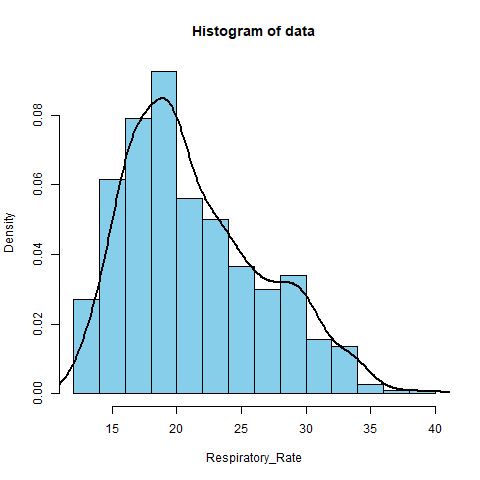

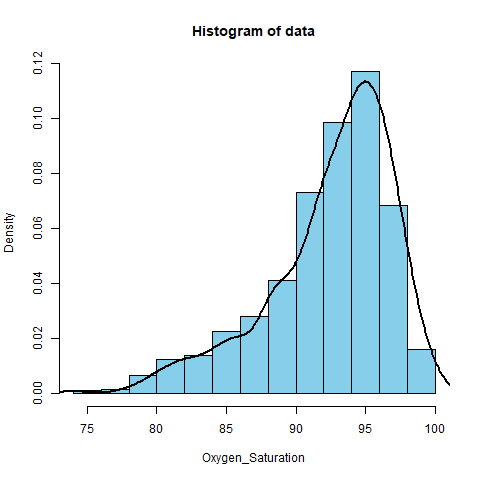

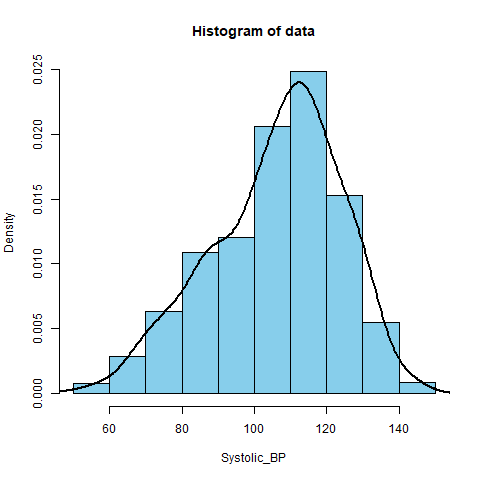

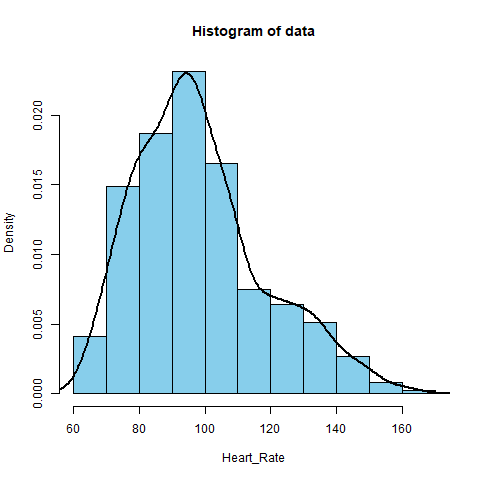

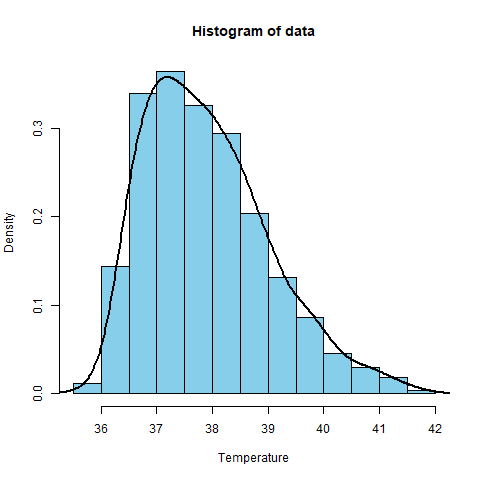

In [6]:
%%R

colomns_for_print <- c('Respiratory_Rate', 'Oxygen_Saturation', 'Systolic_BP', 'Heart_Rate', 'Temperature')
for(i in 1:length(colomns_for_print)) {
    col_name <- colomns_for_print[i]
    data <- ds[[col_name]]
    hist(data, prob=TRUE, col='skyblue', border='black', xlab = col_name)
    lines(density(data), col = 'black', lwd = 2)
}

## 3. Реализовать анализ данных с помощью cdplot, dotchart, boxplot и stripchart.

### 3.1 cdplot

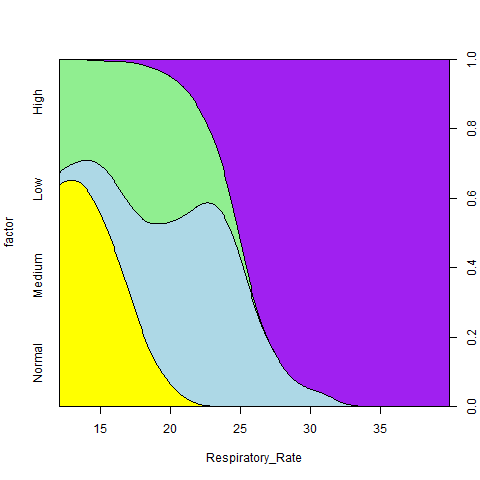

In [7]:
%%R

ds$factor <- as.factor(ds$Risk_Level)
cdplot(factor ~ Respiratory_Rate, data = ds, col = c("yellow", "lightblue", "lightgreen", "purple"))

### 3.2 dotchart

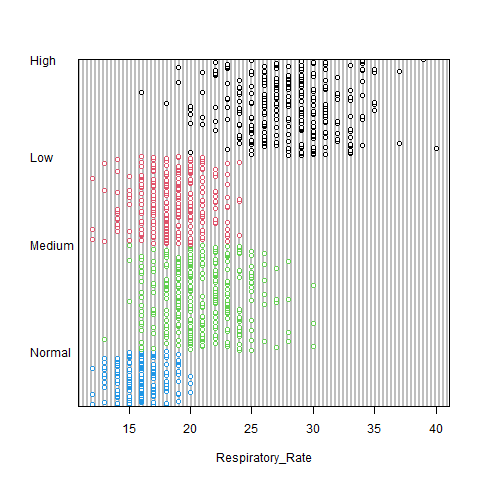

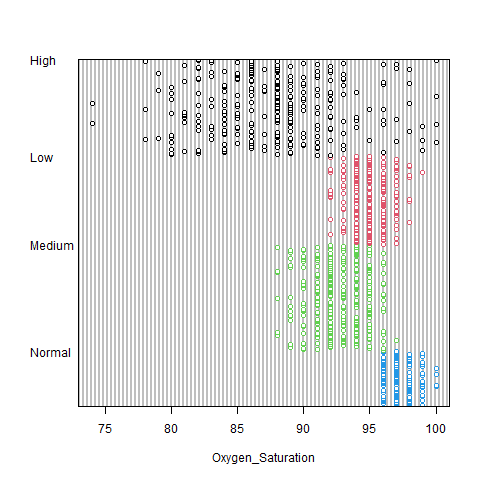

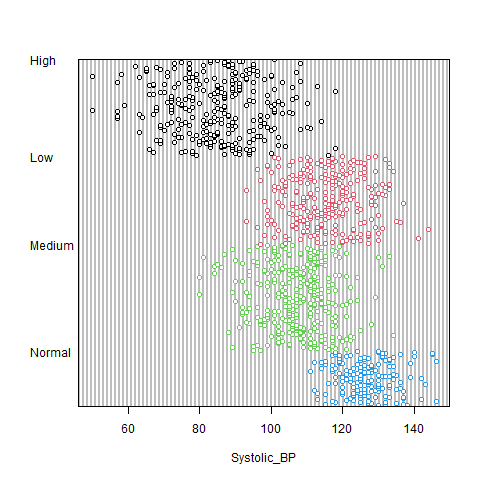

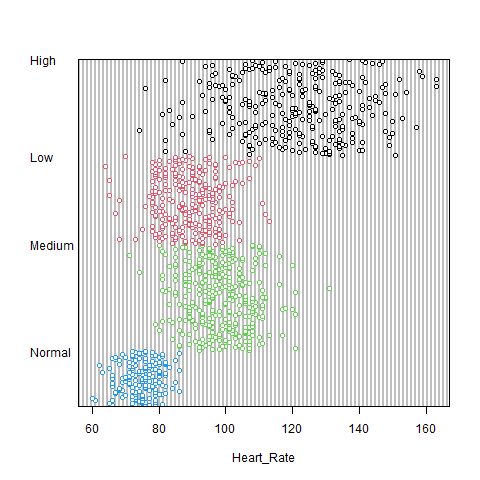

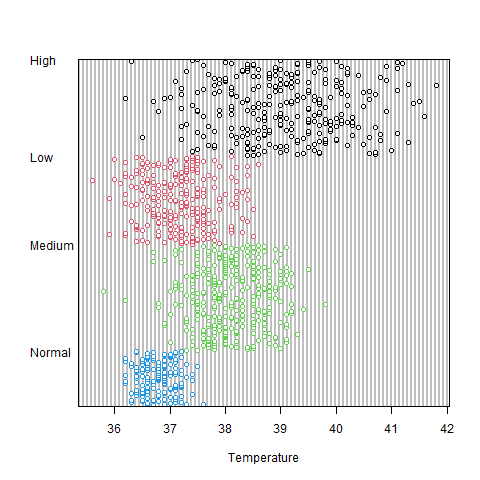

In [8]:
%%R

for(i in 1:length(colomns_for_print)) {
    col_name <- colomns_for_print[i]
    factor <- as.factor(ds$Risk_Level)
    dotchart(ds[[col_name]], groups = factor, color = as.numeric(factor), xlab = col_name)
}

### 3.3 boxplot

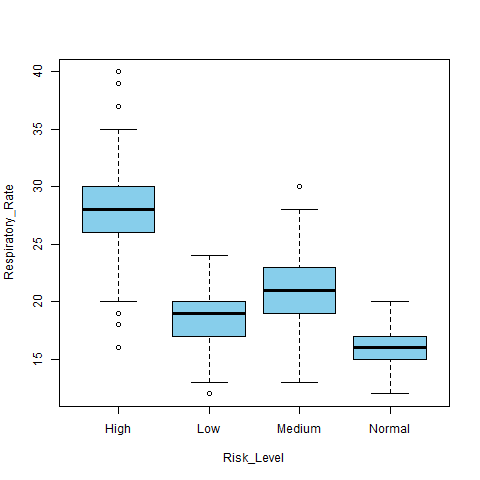

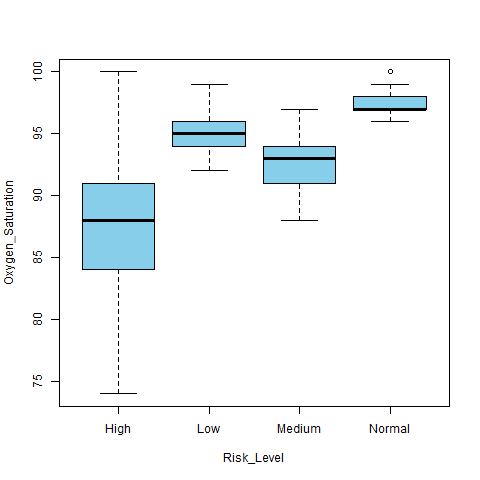

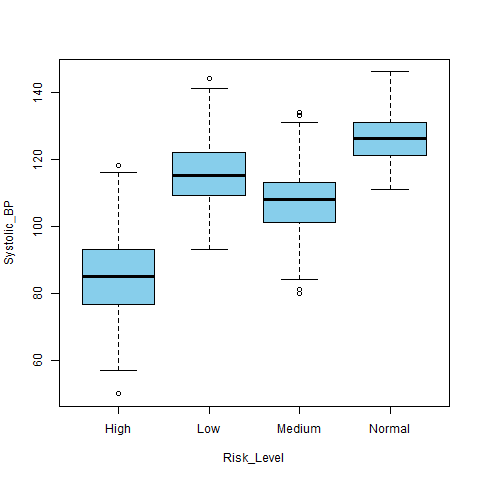

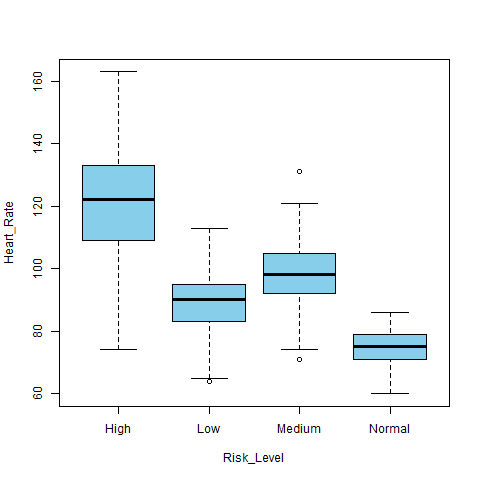

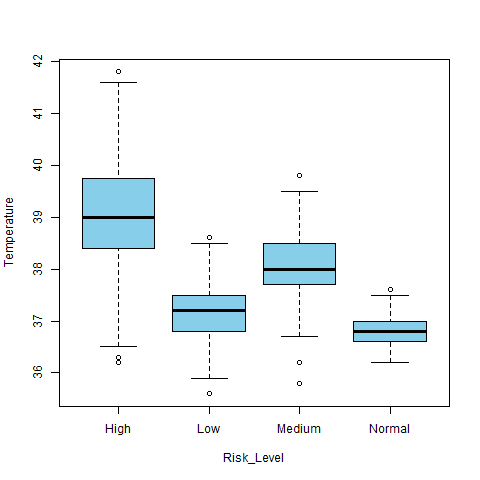

In [9]:
%%R

for(i in 1:length(colomns_for_print)) {
    col_name <- colomns_for_print[i]
    boxplot(ds[[col_name]] ~ ds$Risk_Level, col = 'skyblue', xlab = 'Risk_Level', ylab = col_name)
}

### 3.4 stripchart

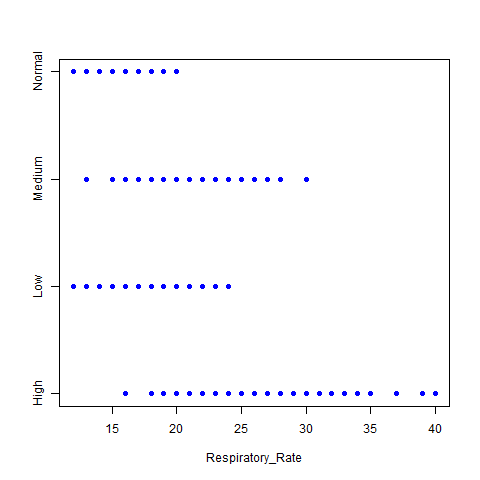

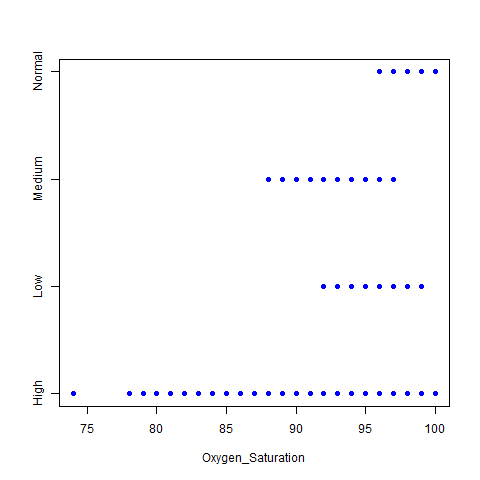

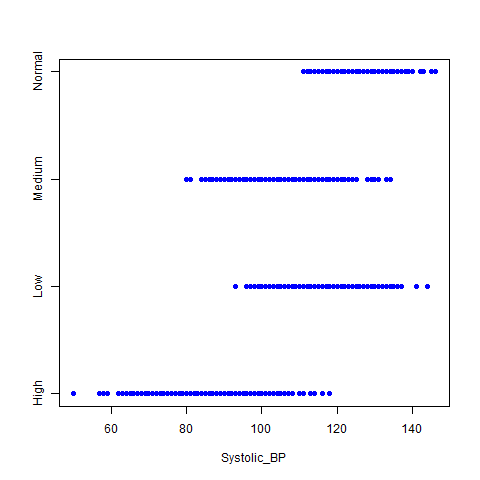

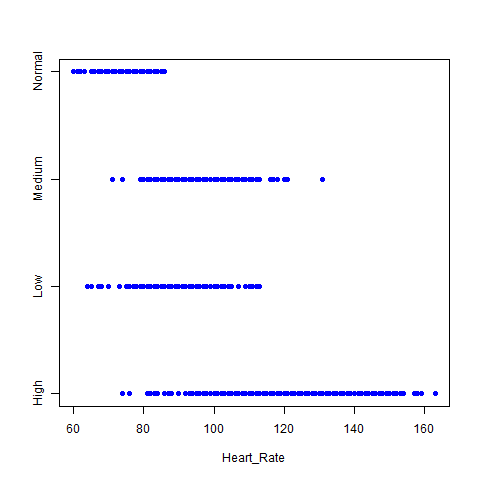

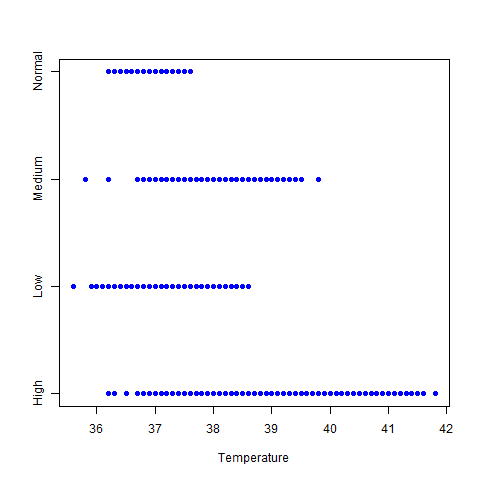

In [10]:
%%R

for(i in 1:length(colomns_for_print)){
    col_name <- colomns_for_print[i]
    stripchart(ds[[col_name]] ~ ds$Risk_Level, xlab = col_name, col = "blue", pch = 16)
}

## 4. Проверить, являются ли наблюдения выбросами с точки зрения формальных статистических критериев Граббса и Q-теста Диксона. Визуализировать результаты. 

### 4.1 Критерий Граббса

In [11]:
%%R

for(i in 1:length(colomns_for_print)) {
    col_name <- colomns_for_print[i]
    data <- ds[[col_name]]
    print(col_name)
    print(grubbs.test(data))
}

[1] "Respiratory_Rate"

	Grubbs test for one outlier

data:  data
G = 3.49673, U = 0.98775, p-value = 0.2269
alternative hypothesis: highest value 40 is an outlier

[1] "Oxygen_Saturation"

	Grubbs test for one outlier

data:  data
G = 4.15603, U = 0.98269, p-value = 0.01502
alternative hypothesis: lowest value 74 is an outlier

[1] "Systolic_BP"

	Grubbs test for one outlier

data:  data
G = 3.13786, U = 0.99013, p-value = 0.8309
alternative hypothesis: lowest value 50 is an outlier

[1] "Heart_Rate"

	Grubbs test for one outlier

data:  data
G = 3.27704, U = 0.98924, p-value = 0.5098
alternative hypothesis: highest value 163 is an outlier

[1] "Temperature"

	Grubbs test for one outlier

data:  data
G = 3.48300, U = 0.98784, p-value = 0.239
alternative hypothesis: highest value 41.8 is an outlier



### 4.2 Q-тест Диксона

Проблема теста Диксона в том, что он работает не более чем на 30 элементах, поэтому ищем в конкретном месте выброс

In [12]:
%%R

data <- rnorm(30, mean=0, sd=1)
dixon.test(data)


	Dixon test for outliers

data:  data
Q = 0.18019, p-value = 0.9986
alternative hypothesis: lowest value -2.34743582357715 is an outlier



In [13]:
%%R

data <- ds$Oxygen_Saturation[350:370]
dixon.test(data)


	Dixon test for outliers

data:  data
Q = 0.6, p-value < 2.2e-16
alternative hypothesis: lowest value 74 is an outlier



## 5. Воспользоваться инструментами для заполнения пропусков в данных. Пропуски внести вручную и сравнить результаты заполнения с истинными значениями. 

In addition: Warning message:
Number of logged events: 1 


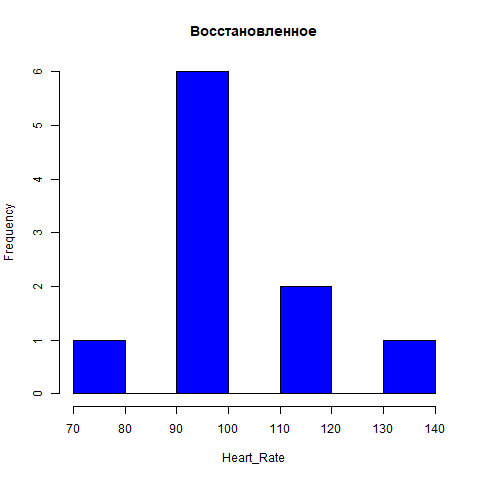

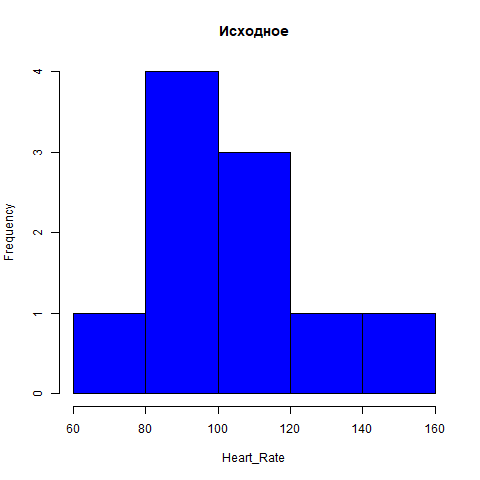

In [14]:
%%R

sp <- ds
sp$Heart_Rate[1:10] <- NA
cat_col <- names(sp)[sapply(sp, is.character)]
for(i in cat_col) {
    sp[[i]] <- as.numeric(factor(sp[[i]]))
}

imp <- mice(sp, method="pmm", m=1, printFlag=FALSE)
sp_imp <- complete(imp)
sp <- as.data.frame(sp_imp)

hist(sp$Heart_Rate[1:10], main="Восстановленное", xlab="Heart_Rate", col="blue")
hist(ds$Heart_Rate[1:10], main="Исходное", xlab="Heart_Rate", col="Blue")

## 6. Сгенерировать данные из нормального распределения с различными параметрами и провести анализ с помощью графиков эмпирических функций распределений, квантилей, метода огибающих, а также стандартных процедур проверки гипотез о нормальности (критерии Колмогорова-Смирнова, ШапироУилка, Андерсона-Дарлинга, Крамера фон Мизеса, Колмогорова-Смирнова в модификации Лиллиефорса и Шапиро-Франсия). Рассмотреть выборки малого (не более 50-100 элементов) и умеренного (1000-5000 наблюдений) объемов

### 6.1 Генерация данных и графики эмчирических функций распределения

In [15]:
%%R

data_1 <- rnorm(2000, 0, 1)
data_2 <- rnorm(2000, 0, 3)
data_3 <- rnorm(2000, 1, 4)
data_4 <- rnorm(75, 5, 8)
data_5 <- rnorm(75, 9, 2)

data_arr <- list(data_1, data_2, data_3, data_4, data_5)

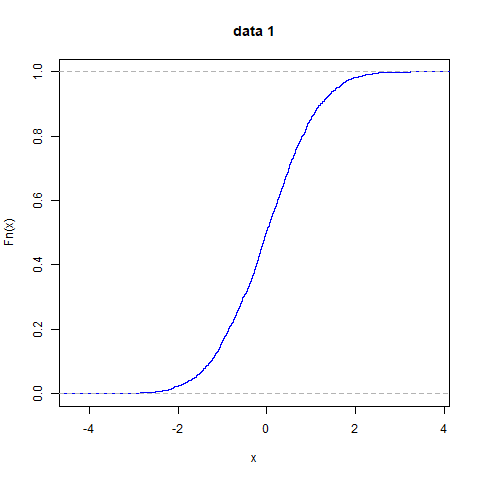

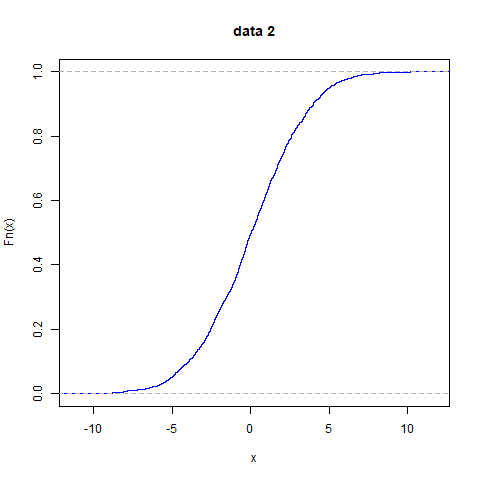

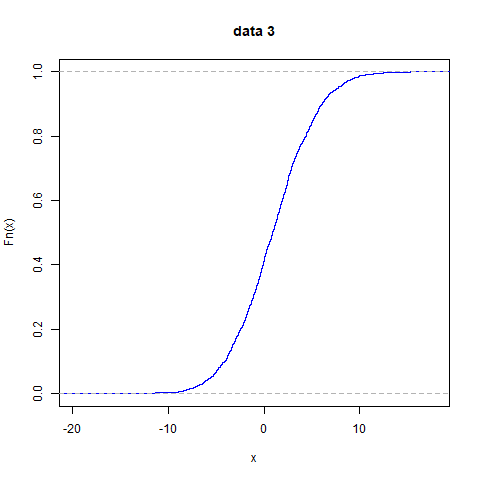

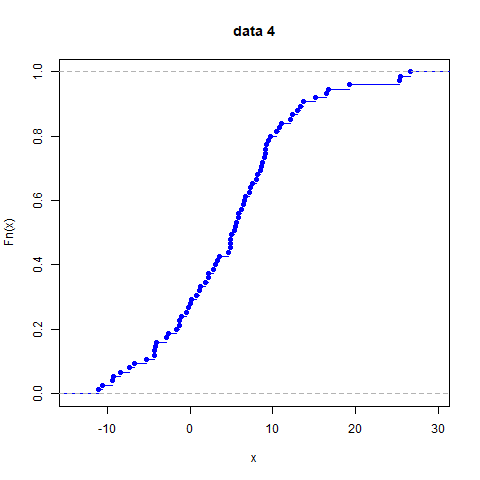

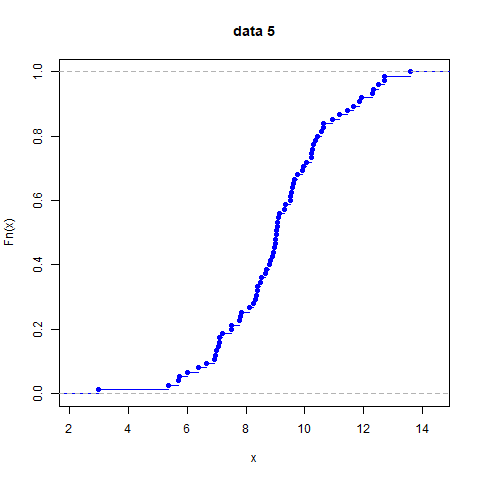

In [16]:
%%R

for(i in 1:5){
    plot(ecdf(data_arr[[i]]), col="blue", main=paste("data", i))
}

### 6.2 Квантили

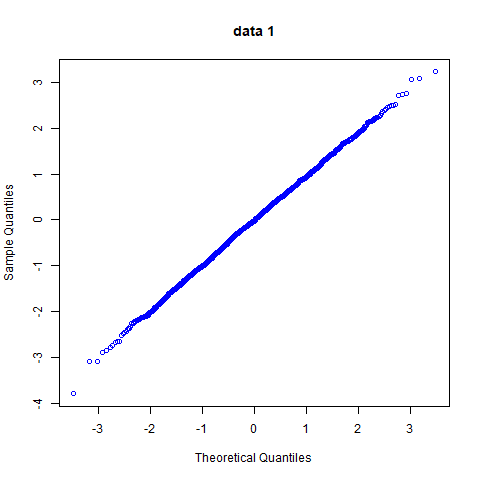

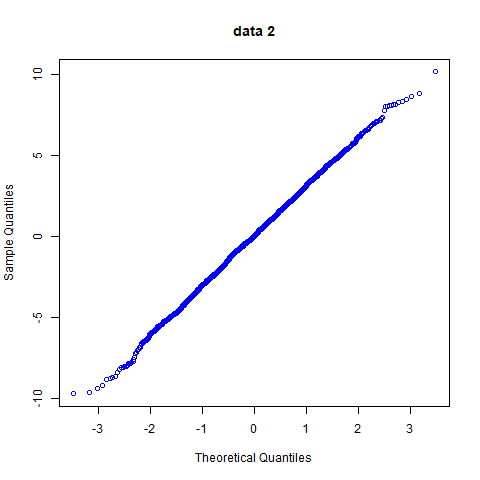

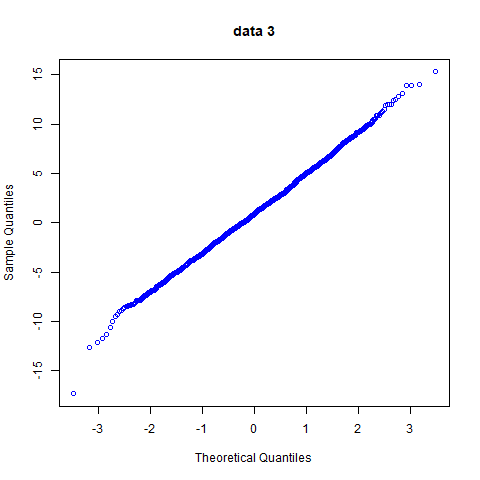

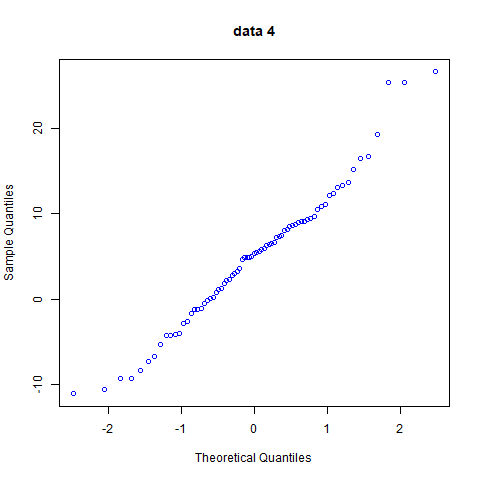

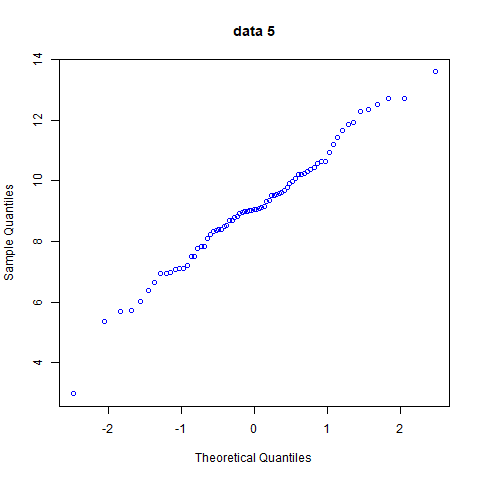

In [17]:
%%R

for(i in 1:5){
    qqnorm(data_arr[[i]], col="blue", main=paste("data", i))
}

### 6.3 Метод огибающих

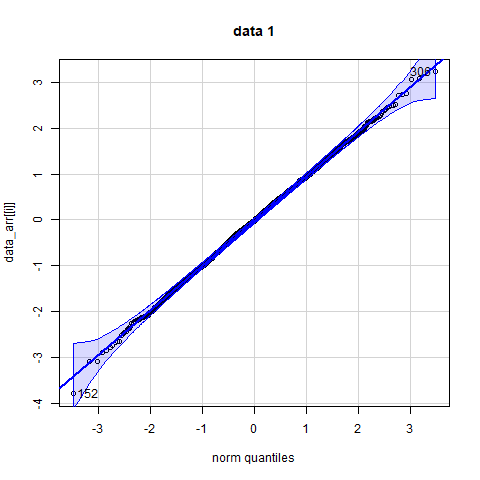

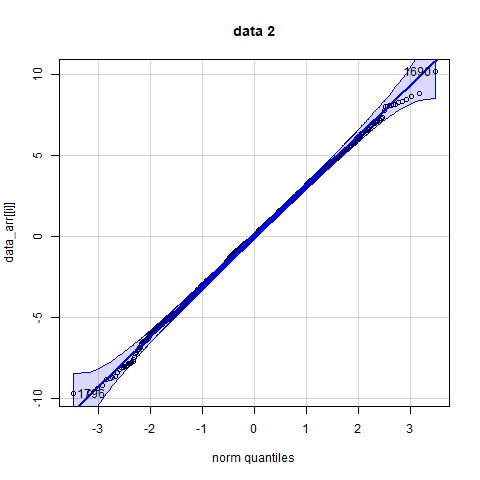

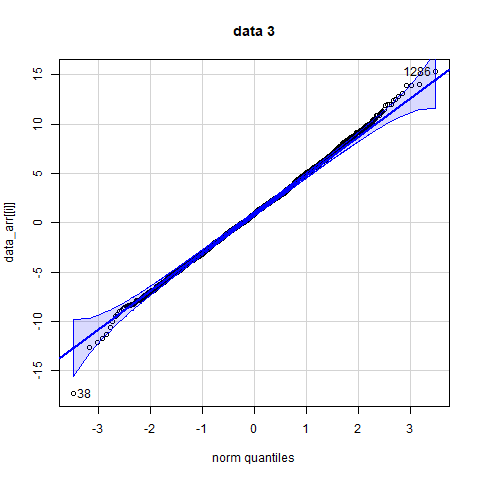

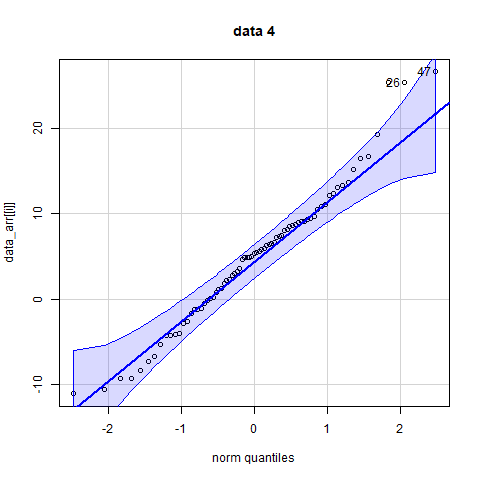

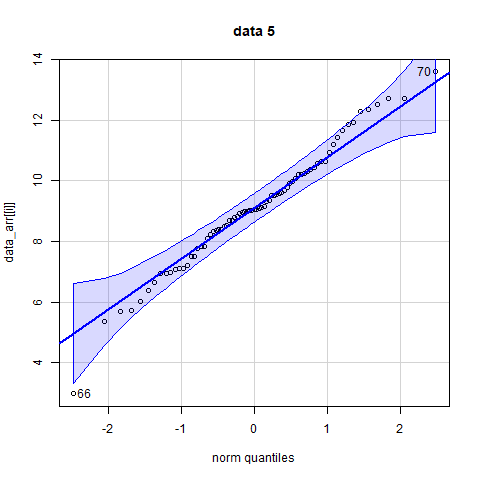

In [18]:
%%R

for(i in 1:5) {
    qqPlot(data_arr[[i]], main=paste("data", i), envelope=0.95)
}

### 6.4 Критерий Колмогорова-Смирнова

In [19]:
%%R

for(i in 1:5) {
    print(ks.test(data_arr[[i]], 'pnorm'))
}


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  data_arr[[i]]
D = 0.017997, p-value = 0.5363
alternative hypothesis: two-sided


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  data_arr[[i]]
D = 0.25656, p-value < 2.2e-16
alternative hypothesis: two-sided


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  data_arr[[i]]
D = 0.37802, p-value < 2.2e-16
alternative hypothesis: two-sided


	Exact one-sample Kolmogorov-Smirnov test

data:  data_arr[[i]]
D = 0.63939, p-value < 2.2e-16
alternative hypothesis: two-sided


	Exact one-sample Kolmogorov-Smirnov test

data:  data_arr[[i]]
D = 0.99853, p-value < 2.2e-16
alternative hypothesis: two-sided



### 6.5 Критерий Шапиро-Уилка

In [20]:
%%R

for(i in 1:5) {
    print(shapiro.test(data_arr[[i]]))
}


	Shapiro-Wilk normality test

data:  data_arr[[i]]
W = 0.99951, p-value = 0.9172


	Shapiro-Wilk normality test

data:  data_arr[[i]]
W = 0.9992, p-value = 0.5523


	Shapiro-Wilk normality test

data:  data_arr[[i]]
W = 0.99876, p-value = 0.1639


	Shapiro-Wilk normality test

data:  data_arr[[i]]
W = 0.97649, p-value = 0.1764


	Shapiro-Wilk normality test

data:  data_arr[[i]]
W = 0.98597, p-value = 0.5781



### 6.6 Критерий Андерсона-Дарлинга

In [21]:
%%R

for(i in 1:5) {
    print(ad.test(data_arr[[i]]))
}


	Anderson-Darling normality test

data:  data_arr[[i]]
A = 0.30171, p-value = 0.5774


	Anderson-Darling normality test

data:  data_arr[[i]]
A = 0.28661, p-value = 0.6228


	Anderson-Darling normality test

data:  data_arr[[i]]
A = 0.41756, p-value = 0.3294


	Anderson-Darling normality test

data:  data_arr[[i]]
A = 0.38873, p-value = 0.3769


	Anderson-Darling normality test

data:  data_arr[[i]]
A = 0.34006, p-value = 0.489



### 6.7 Критерий Крамера фон Мизеса

In [22]:
%%R

for(i in 1:5) {
    print(cvm.test(data_arr[[i]]))
}


	Cramer-von Mises normality test

data:  data_arr[[i]]
W = 0.056967, p-value = 0.4146


	Cramer-von Mises normality test

data:  data_arr[[i]]
W = 0.047598, p-value = 0.5459


	Cramer-von Mises normality test

data:  data_arr[[i]]
W = 0.071285, p-value = 0.269


	Cramer-von Mises normality test

data:  data_arr[[i]]
W = 0.049354, p-value = 0.5147


	Cramer-von Mises normality test

data:  data_arr[[i]]
W = 0.058755, p-value = 0.3883



### 6.8 Критерий Колмогорова-Смирнова в модификации Лиллиефорса и Шапиро-Франсия

In [23]:
%%R

for(i in 1:5) {
    print(lillie.test(data_arr[[i]]))
}


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data_arr[[i]]
D = 0.015848, p-value = 0.2588


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data_arr[[i]]
D = 0.016917, p-value = 0.1791


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data_arr[[i]]
D = 0.018948, p-value = 0.09214


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data_arr[[i]]
D = 0.075382, p-value = 0.3645


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data_arr[[i]]
D = 0.062585, p-value = 0.6629



## 7. Продемонстрировать пример анализа данных с помощью графиков квантилей, метода огибающих, а также стандартных процедур проверки гипотез о нормальности. Рассмотреть выборки малого и умеренного объемов

In [24]:
%%R

data_1 <- ds[['Heart_Rate']]
data_2 <- ds[['Heart_Rate']][50:100]

### 7.1 Квантили

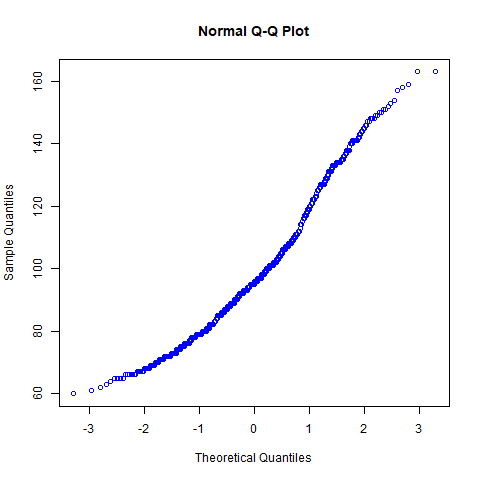

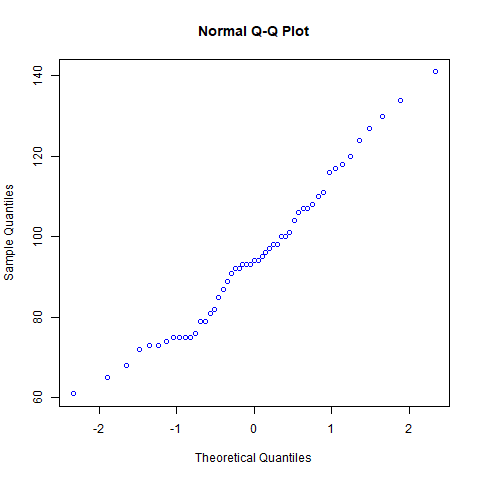

In [25]:
%%R

qqnorm(data_1, col='blue')
qqnorm(data_2, col='blue')

### 7.2 Анализ с помощью метода огибающих

[1] 1690 1796


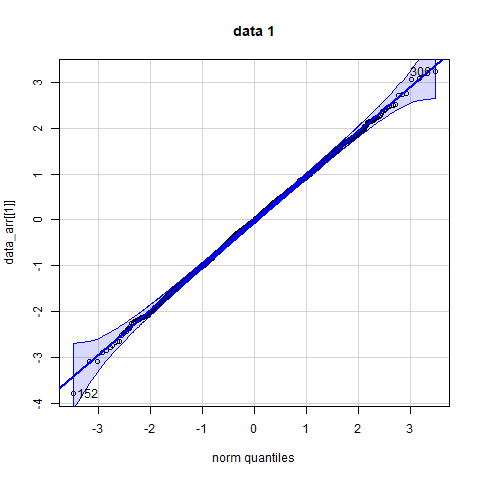

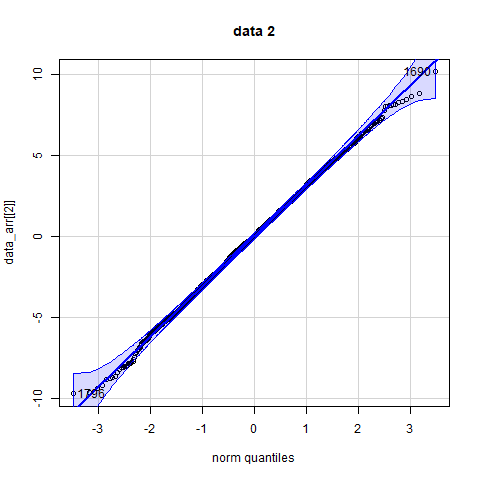

In [26]:
%%R

qqPlot(data_arr[[1]], main=paste("data", 1), envelope=0.95)
qqPlot(data_arr[[2]], main=paste("data", 2), envelope=0.95)

### 7.3 Гипотезы о нормальности

In [27]:
%%R

print(ks.test(data_1, 'pnorm'))
print(shapiro.test(data_1))
print(ad.test(data_1))
print(cvm.test(data_1))
print(lillie.test(data_1))


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  data_1
D = 1, p-value < 2.2e-16
alternative hypothesis: two-sided


	Shapiro-Wilk normality test

data:  data_1
W = 0.96141, p-value = 1.345e-15


	Anderson-Darling normality test

data:  data_1
A = 10.921, p-value < 2.2e-16


	Cramer-von Mises normality test

data:  data_1
W = 1.7524, p-value = 7.37e-10


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data_1
D = 0.082691, p-value < 2.2e-16



R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xe2 in position 1: invalid continuation byte <traceback object at 0x000001CB5B78E180>


In addition: Warning messages:
1: In ks.test.default(data_1, "pnorm") :
 2: In cvm.test(data_1) :
  p-value is smaller than 7.37e-10, cannot be computed more accurately


In [28]:
%%R

print(ks.test(data_2, 'pnorm'))
print(shapiro.test(data_2))
print(ad.test(data_2))
print(cvm.test(data_2))
print(lillie.test(data_2))


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  data_2
D = 1, p-value < 2.2e-16
alternative hypothesis: two-sided


	Shapiro-Wilk normality test

data:  data_2
W = 0.9732, p-value = 0.299


	Anderson-Darling normality test

data:  data_2
A = 0.41727, p-value = 0.3187


	Cramer-von Mises normality test

data:  data_2
W = 0.059628, p-value = 0.3759


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data_2
D = 0.07939, p-value = 0.5845



R callback write-console: <class 'UnicodeDecodeError'> 'utf-8' codec can't decode byte 0xe2 in position 1: invalid continuation byte <traceback object at 0x000001CB5B78DD40>


In addition: Warning message:
In ks.test.default(data_2, "pnorm") :
 